In [1]:
# For developments outside of the controlgym working directory: use pip install controlgym==1.0.0 to install the package
import numpy as np
import controlgym as gym

In [2]:
LINEAR_PDE_IDS = {"convection_diffusion_reaction", "wave", "schrodinger"}
VALID_CTRL_MODES = {"lqg", "lqr"}


def _is_2d_array(x) -> bool:
    """Return True if x is a NumPy matrix-like 2D array."""
    return isinstance(x, np.ndarray) and x.ndim == 2


def _validate_inputs(env_id: str, ctrl_mode: str, n_traj: int) -> None:
    if ctrl_mode not in VALID_CTRL_MODES:
        raise ValueError("ctrl_mode must be 'lqg' or 'lqr'.")
    if env_id not in LINEAR_PDE_IDS:
        raise ValueError(
            f"{env_id} is nonlinear in controlgym. LQG/LQR are supported only for {LINEAR_PDE_IDS}."
        )
    if n_traj <= 0:
        raise ValueError("n_traj must be a positive integer.")


def _make_envs(env_id: str, **env_kwargs):
    env_init = gym.make(env_id, **env_kwargs)
    env_zero = gym.make(env_id, **env_kwargs)
    env_ctrl = gym.make(env_id, **env_kwargs)
    return env_init, env_zero, env_ctrl


def _make_controllers(env_zero, env_ctrl, ctrl_mode: str):
    zero = gym.controllers.Zero(env_zero)
    ctrl = gym.controllers.LQG(env_ctrl) if ctrl_mode == "lqg" else gym.controllers.LQR(env_ctrl)

    if ctrl_mode == "lqg":
        if getattr(env_ctrl, "sensor_noise_cov", 0.0) <= 0:
            raise ValueError("LQG requires sensor_noise_cov > 0.")
        if not _is_2d_array(ctrl.gain_lqr):
            raise RuntimeError("LQG gain_lqr is invalid. Try different env/noise settings.")
        if not _is_2d_array(ctrl.gain_kf):
            raise RuntimeError(
                "LQG gain_kf is invalid (not a matrix). "
                "Try setting n_observation=n_state and positive process/sensor noise covariances."
            )
    return zero, ctrl


def _sample_initial_state(env_init, seed: int) -> np.ndarray:
    _, info = env_init.reset(seed=seed)
    return info["state"].copy()


def _select_action(mode: str, controller, current_state: np.ndarray, est_state: np.ndarray | None):
    if mode == "zero":
        return controller.select_action()
    if mode == "lqr":
        return controller.select_action(current_state)
    if mode == "lqg":
        return controller.select_action(est_state)
    raise ValueError(f"Unknown mode: {mode}")


def rollout_with_actions(env, controller, mode: str, x0: np.ndarray, noise_seed: int):
    """Run one rollout and return X, U, reward sum, and valid horizon T."""
    _, info = env.reset(seed=noise_seed, state=x0)
    current_state = info["state"]

    X = np.full((env.n_state, env.n_steps + 1), np.nan)
    U = np.full((env.n_action, env.n_steps), np.nan)
    X[:, 0] = current_state

    total_reward = 0.0
    est_state = current_state.copy() if mode == "lqg" else None
    use_kf = mode == "lqg" and _is_2d_array(getattr(controller, "gain_kf", None))

    for t in range(env.n_steps):
        u = _select_action(mode, controller, current_state, est_state)
        obs, reward, terminated, truncated, info = env.step(u)

        current_state = info["state"]
        X[:, t + 1] = current_state
        U[:, t] = u
        total_reward += reward

        if terminated or truncated:
            T = t + 1
            return X[:, : T + 1], U[:, : T], total_reward, T

        if mode == "lqg":
            if use_kf:
                est_state = controller.evolve_state_estimate(est_state, u, obs)
            else:
                est_state = current_state.copy()

    return X, U, total_reward, env.n_steps


def _compute_control_field(B2: np.ndarray, U: np.ndarray) -> np.ndarray:
    return B2 @ U


def _allocate_dataset_arrays(n_traj: int, n_state: int, n_action: int, n_steps: int):
    return {
        "init_states": np.zeros((n_traj, n_state)),
        "X_zero": np.full((n_traj, n_state, n_steps + 1), np.nan),
        "U_zero": np.full((n_traj, n_action, n_steps), np.nan),
        "control_field_zero": np.full((n_traj, n_state, n_steps), np.nan),
        "R_zero": np.zeros(n_traj),
        "T_zero": np.zeros(n_traj, dtype=int),
        "X_ctrl": np.full((n_traj, n_state, n_steps + 1), np.nan),
        "U_ctrl": np.full((n_traj, n_action, n_steps), np.nan),
        "control_field_ctrl": np.full((n_traj, n_state, n_steps), np.nan),
        "R_ctrl": np.zeros(n_traj),
        "T_ctrl": np.zeros(n_traj, dtype=int),
    }


def _store_one_rollout(X_buf, U_buf, F_buf, R_buf, T_buf, B2: np.ndarray, k: int, X, U, R: float, T: int):
    X_buf[k, :, : X.shape[1]] = X
    U_buf[k, :, : U.shape[1]] = U
    F = _compute_control_field(B2, U)
    F_buf[k, :, : F.shape[1]] = F
    R_buf[k] = R
    T_buf[k] = T


def generate_controlled_dataset(
    env_id: str,
    n_traj: int,
    ctrl_mode: str = "lqg",
    init_seed: int = 123,
    noise_seed: int = 10_000,
    **env_kwargs,
):
    _validate_inputs(env_id, ctrl_mode, n_traj)
    env_init, env_zero, env_ctrl = _make_envs(env_id, **env_kwargs)
    zero, ctrl = _make_controllers(env_zero, env_ctrl, ctrl_mode)

    n_state, n_action, n_steps = env_zero.n_state, env_zero.n_action, env_zero.n_steps
    out = _allocate_dataset_arrays(n_traj, n_state, n_action, n_steps)

    B2_zero = env_zero.B2.copy()
    B2_ctrl = env_ctrl.B2.copy()

    for k in range(n_traj):
        x0 = _sample_initial_state(env_init, seed=init_seed + k)
        out["init_states"][k] = x0

        seed_k = noise_seed + k
        xz, uz, rz, tz = rollout_with_actions(env_zero, zero, "zero", x0, seed_k)
        xc, uc, rc, tc = rollout_with_actions(env_ctrl, ctrl, ctrl_mode, x0, seed_k)

        _store_one_rollout(out["X_zero"], out["U_zero"], out["control_field_zero"],
                           out["R_zero"], out["T_zero"], B2_zero, k, xz, uz, rz, tz)
        _store_one_rollout(out["X_ctrl"], out["U_ctrl"], out["control_field_ctrl"],
                           out["R_ctrl"], out["T_ctrl"], B2_ctrl, k, xc, uc, rc, tc)

    out["env_id"] = env_id
    out["ctrl_mode"] = ctrl_mode
    out["env_kwargs"] = dict(env_kwargs)
    out["B2_zero"] = B2_zero
    out["B2_ctrl"] = B2_ctrl
    return out


In [ ]:
data = generate_controlled_dataset(
    env_id="wave",
    n_traj=10,
    ctrl_mode="lqg",
    n_state=200,
    n_observation=200,
    n_action=8,
    n_steps=200,
    process_noise_cov=1e-5,
    sensor_noise_cov=0.05,
    init_seed=123,
)

In [4]:
print("Generated keys:", list(data.keys()))


Generated keys: ['init_states', 'X_zero', 'U_zero', 'control_field_zero', 'R_zero', 'T_zero', 'X_ctrl', 'U_ctrl', 'control_field_ctrl', 'R_ctrl', 'T_ctrl', 'env_id', 'ctrl_mode', 'env_kwargs', 'B2_zero', 'B2_ctrl']


In [5]:
# 2) Check shapes of 2 random trajectories
import numpy as np

rng = np.random.default_rng(42)
idxs = rng.choice(data["X_zero"].shape[0], size=2, replace=False)

for i in idxs:
    print(f"\nTrajectory {i}")
    print("X_zero:", data["X_zero"][i].shape)
    print("U_zero:", data["U_zero"][i].shape)
    print("control_field_zero:", data["control_field_zero"][i].shape)
    print("X_ctrl:", data["X_ctrl"][i].shape)
    print("U_ctrl:", data["U_ctrl"][i].shape)
    print("control_field_ctrl:", data["control_field_ctrl"][i].shape)
    print("T_zero / T_ctrl:", data["T_zero"][i], data["T_ctrl"][i])


Trajectory 0
X_zero: (200, 201)
U_zero: (8, 200)
control_field_zero: (200, 200)
X_ctrl: (200, 201)
U_ctrl: (8, 200)
control_field_ctrl: (200, 200)
T_zero / T_ctrl: 200 200

Trajectory 7
X_zero: (200, 201)
U_zero: (8, 200)
control_field_zero: (200, 200)
X_ctrl: (200, 201)
U_ctrl: (8, 200)
control_field_ctrl: (200, 200)
T_zero / T_ctrl: 200 200


[traj=8 | mode=zero] X shape = (200, 201), T = 200


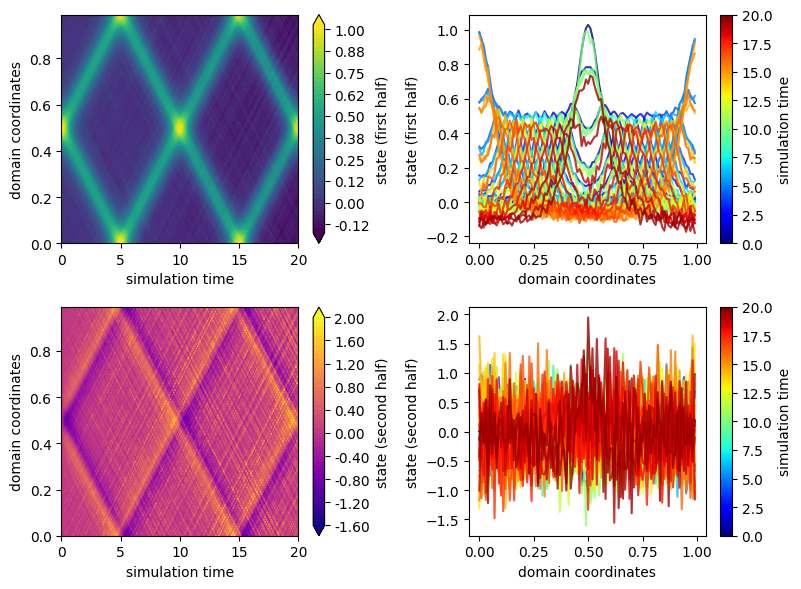

[traj=8 | mode=ctrl] X shape = (200, 201), T = 200


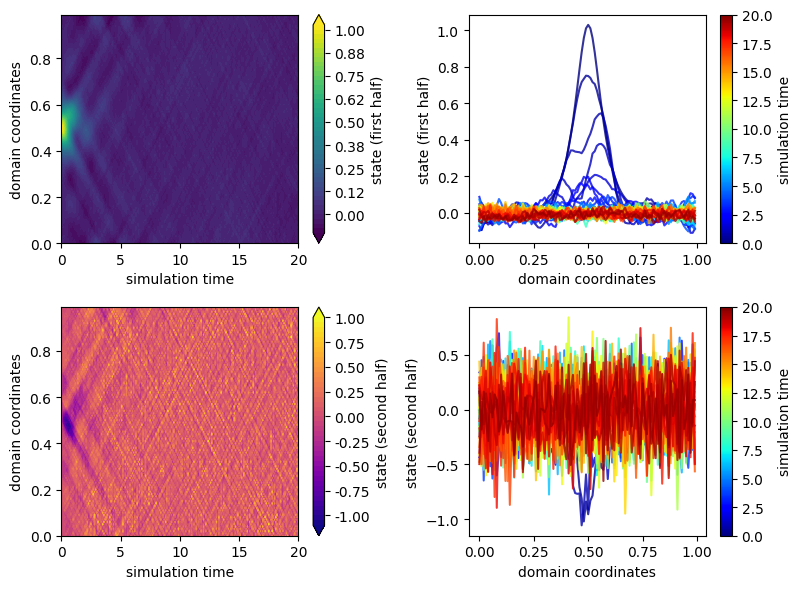

[traj=6 | mode=zero] X shape = (200, 201), T = 200


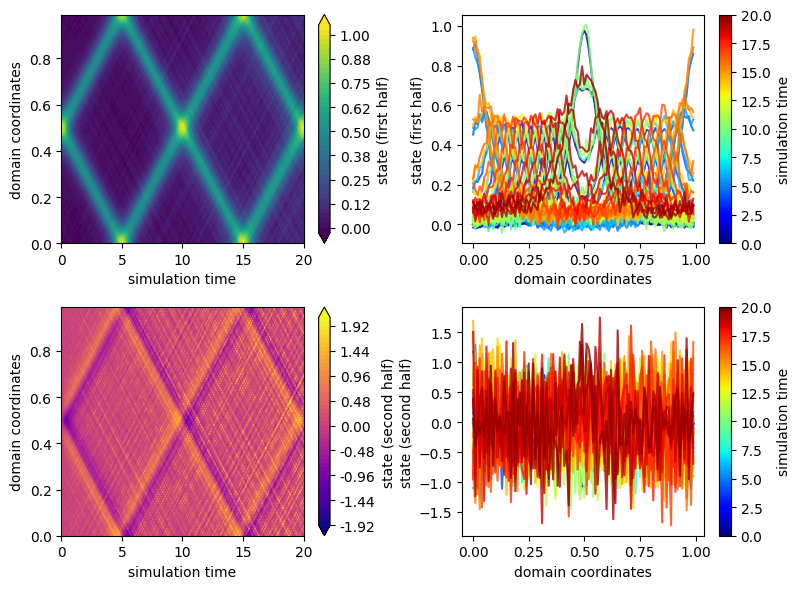

[traj=6 | mode=ctrl] X shape = (200, 201), T = 200


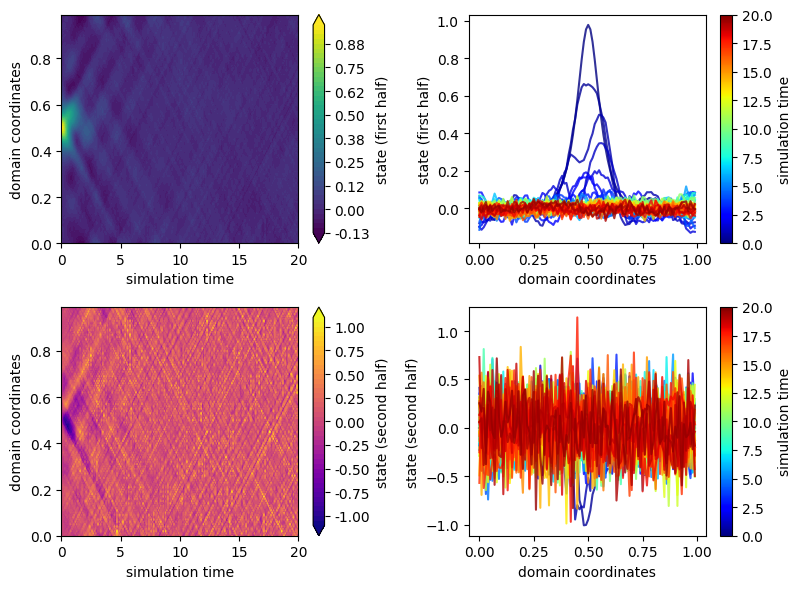

In [ ]:
import tempfile
from controlgym.helpers.plotting import _plot_pde, _plot_coupled_pde
import matplotlib.pyplot as plt

def _plot_single_from_data(data, traj_idx: int, mode: str, contour=True, surface3d=False, dpi=300):
    """
    Plot one trajectory from `data` in the same style as gym.save(...).

    mode:
        "zero" -> uses X_zero / T_zero
        "ctrl" -> uses X_ctrl / T_ctrl
    """
    if mode not in {"zero", "ctrl"}:
        raise ValueError("mode must be 'zero' or 'ctrl'")

    X_key, T_key = ("X_zero", "T_zero") if mode == "zero" else ("X_ctrl", "T_ctrl")

    env_kwargs = dict(data.get("env_kwargs", {}))
    env = gym.make(data["env_id"], **env_kwargs)

    T = int(data[T_key][traj_idx])
    X = data[X_key][traj_idx, :, : T + 1]  # crop valid horizon

    env.n_steps = T
    env.state_traj = X

    print(f"[traj={traj_idx} | mode={mode}] X shape = {X.shape}, T = {T}")

    # plotting helpers require a save dir even if display=True
    with tempfile.TemporaryDirectory() as tmpdir:
        if env.id in ["wave", "schrodinger"]:
            _plot_coupled_pde(
                env,
                save_dir=tmpdir,
                display=True,
                contour=contour,
                surface3d=surface3d,
                dpi=dpi,
            )
        else:
            _plot_pde(
                env,
                save_dir=tmpdir,
                display=True,
                contour=contour,
                surface3d=surface3d,
                dpi=dpi,
            )

def plot_two_random_trajectories(data, seed=42, contour=True, surface3d=False, dpi=300):
    """
    Plot zero and controlled versions for 2 random trajectories from dataset `data`.
    """
    n = data["X_zero"].shape[0]
    k = min(2, n)
    idxs = np.random.default_rng(seed).choice(n, size=k, replace=False)

    for i in idxs:
        _plot_single_from_data(data, int(i), mode="zero", contour=contour, surface3d=surface3d, dpi=dpi)
        _plot_single_from_data(data, int(i), mode="ctrl", contour=contour, surface3d=surface3d, dpi=dpi)

# Usage:
plot_two_random_trajectories(data, seed=7, contour=True, surface3d=False, dpi=300)


[traj=0 | mode=zero] X shape = (200, 201), T = 200


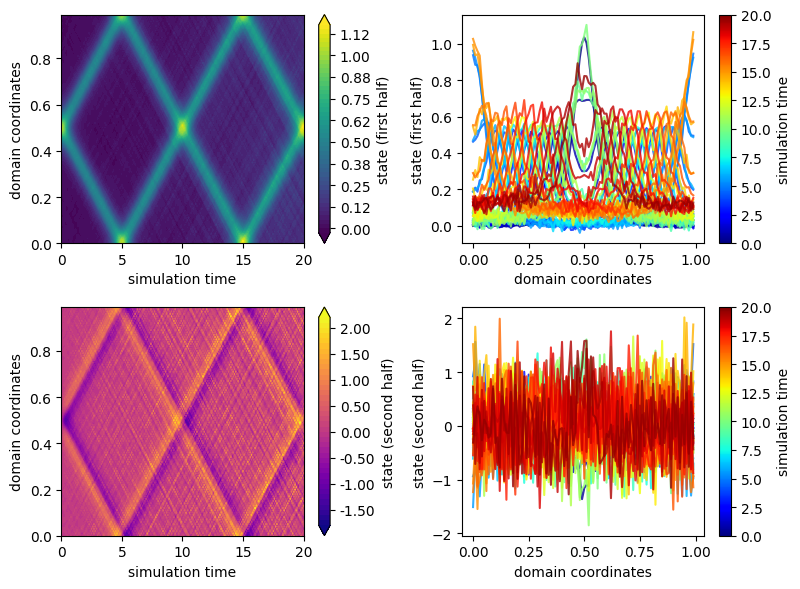

[traj=0 | mode=ctrl] X shape = (200, 201), T = 200


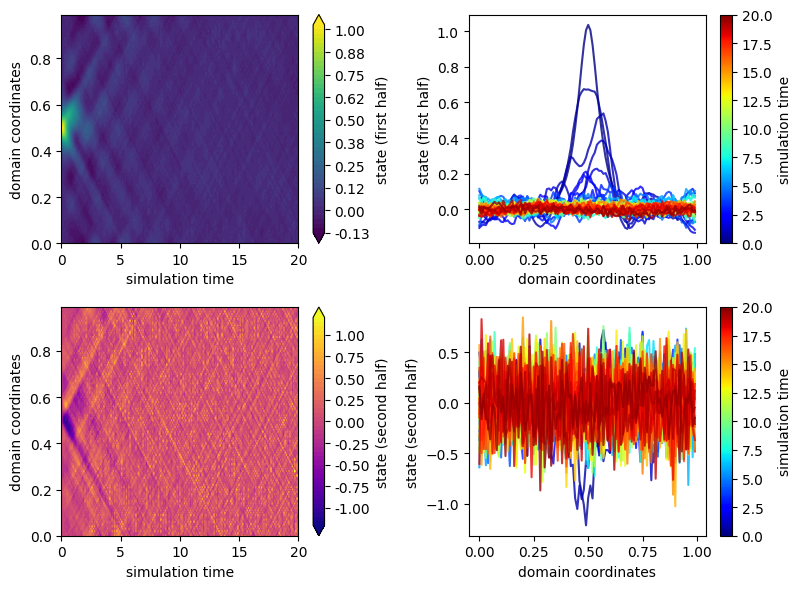

In [10]:
seed=42, 
contour=True 
surface3d=False 
dpi=300

n = data["X_zero"].shape[0]
i = np.random.default_rng(seed).choice(n)

_plot_single_from_data(data, int(i), mode="zero", contour=contour, surface3d=surface3d, dpi=dpi)
_plot_single_from_data(data, int(i), mode="ctrl", contour=contour, surface3d=surface3d, dpi=dpi)